# Supervised Learning Modeling

The goal of this notebook is to train and compare different **classification models** (supervised learning) to determine whether or not fraud has occurred.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load preprocessed data

In [2]:
# Load preprocessed datasets
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

X_train_resampled = pd.read_csv('../data/processed/X_train_resampled.csv')
y_train_resampled = pd.read_csv('../data/processed/y_train_resampled.csv').squeeze()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"X_train_resampled: {X_train_resampled.shape}")

X_train: (227845, 30) | X_test: (56962, 30)
X_train_resampled: (454902, 30)


In [3]:
# Evaluate model function (for all models)
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained model and display key metrics.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*50}")
    print(f" {model_name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    axes[0].set_title(f'{model_name} - Confusion Matrix')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, color='crimson', lw=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
    axes[1].set_title(f'{model_name} - ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'auc_roc': auc,
            'precision': cm[1,1] / (cm[0,1] + cm[1,1]),
            'recall': cm[1,1] / (cm[1,0] + cm[1,1])}

## 2. Logistic Regression (baseline)

Logistic Regression is our baseline model.

- Simple, fast, and interpretable
- Assumes a **linear decision boundary** between classes
- Trained on SMOTE resampled data (balanced classes)
- No `class_weight` needed since SMOTE already balances the training set

Key question: **how many frauds does it miss?**

False negatives = undetected fraud = real financial loss for the bank.

In [4]:
# Train on SMOTE-resampled data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi


 Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC-ROC: 0.9699


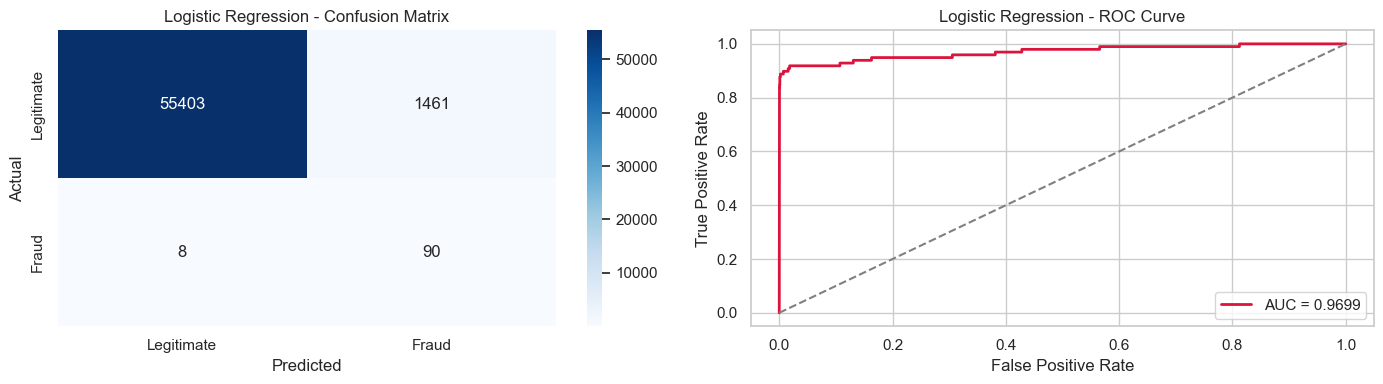

In [5]:
# Evaluate on original test set
lr_results = evaluate_model(lr, X_test, y_test, "Logistic Regression")

### Logistic Regression - Results

| Metric | Value |
|---|---|
| Recall (fraud) | 0.92 |
| Precision (fraud) | 0.06 |
| F1-score (fraud) | 0.11 |
| AUC-ROC | 0.9698 |
| Missed frauds (FN) | 8 / 98 |
| False alerts (FP) | 1458 |

**Fraud Recall** = 0.92: the model detects 90 out of 98 fraud cases. Only 8 were missed. This is very good for a logistic regression model.

**Fraud Precision** = 0.06: of all transactions classified as fraud, only 6% are actually fraudulent. The model generates 1,458 false positives for every 90 true positives.

**AUC-ROC** = 0.97: excellent. The ROC curve rises almost vertically, the model effectively separates the classes when the threshold is adjusted.

The 6% precision seems catastrophic, but it’s a deliberate choice related to SMOTE: the model has learned to be very aggressive in catching fraud, at the cost of many false positives.

In a real banking context:
- 8 missed frauds = direct financial losses
- 1,458 false alerts = legitimate customers blocked = friction, dissatisfaction

This is the Precision/Recall trade-off that we will need to adjust with the decision threshold later.

**Conclusion:**
- The model catches 92% of frauds but generates too many false alerts (1,458).
- This is a consequence of SMOTE aggressive rebalancing.
- AUC-ROC of 0.97 confirms strong discriminative power= the precision/recall tradeoff can be tuned via the decision threshold.

## 3. Decision Tree Classifier

Decision Tree builds a flowchart-like structure of binary rules.

- More flexible than Logistic Regression: captures non-linear boundaries
- Prone to overfitting -> `max_depth` is limited to control complexity
- Advantage: fully explainable visually, even to non-technical stakeholders
- Trained on SMOTE resampled data

In [6]:
# Train
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_resampled, y_train_resampled)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no


 Decision Tree
              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.97     56864
       Fraud       0.03      0.90      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.92      0.52     56962
weighted avg       1.00      0.95      0.97     56962

AUC-ROC: 0.9522


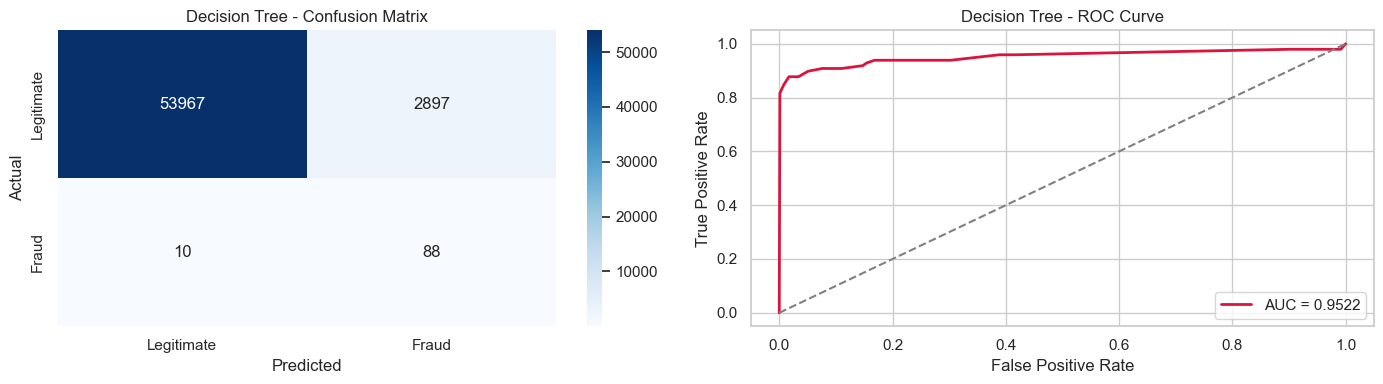

In [7]:
# Evaluate
dt_results = evaluate_model(dt, X_test, y_test, "Decision Tree")

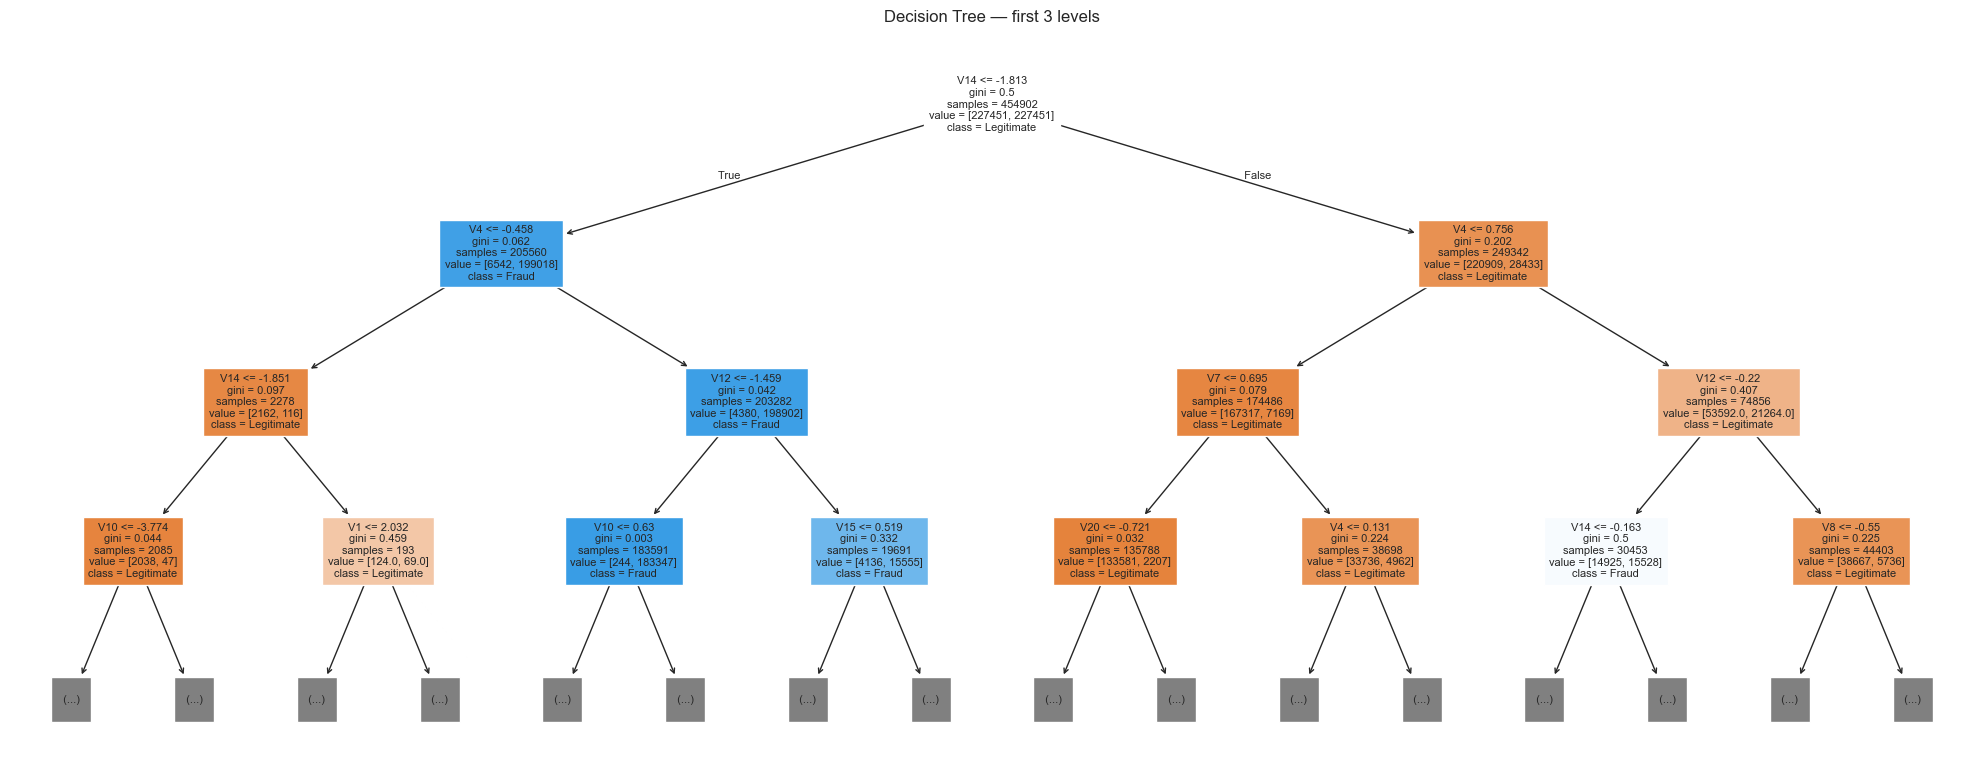

In [8]:
# Visualize the tree
plt.figure(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=X_train.columns,
          class_names=['Legitimate', 'Fraud'],
          filled=True, fontsize=8)
plt.title("Decision Tree — first 3 levels")
plt.tight_layout()
plt.show()

### Decision Tree - Results

| Metric | Value |
|---|---|
| Recall (fraud) | 0.90 |
| Precision (fraud) | 0.03 |
| F1-score (fraud) | 0.06 |
| AUC-ROC | 0.9522 |
| Missed frauds (FN) | 10 / 98 |
| False alerts (FP) | 2896 |

**Interpretation:**

- Decision Tree underperforms vs Logistic Regression baseline.
- First split on V14 confirms EDA findings (strongest correlated feature).
- High number of false alerts (2,896) suggests the single tree overfits the resampled training data.

Random Forest should significantly reduce this variance.

## 4. Random Forest Classifier

Random Forest builds 100 independent decision trees and aggregates their predictions.

- Reduces variance without increasing bias (bagging)
- Each tree is trained on a random subset of data and features
- Much more stable than a single Decision Tree
- Feature importance is a useful byproduct
- Trained on SMOTE resampled data

In [9]:
# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric


 Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9731


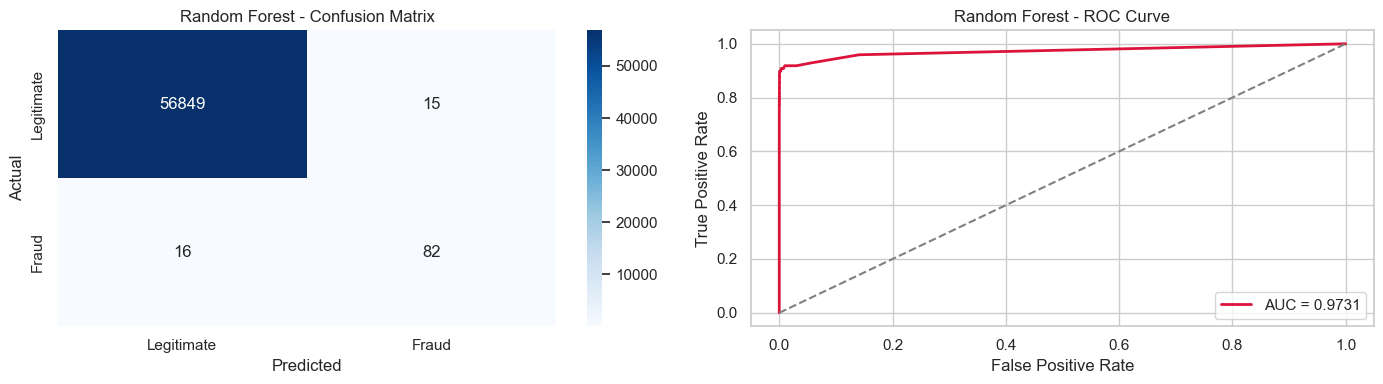

In [10]:
# Evaluate
rf_results = evaluate_model(rf, X_test, y_test, "Random Forest")


 Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9731


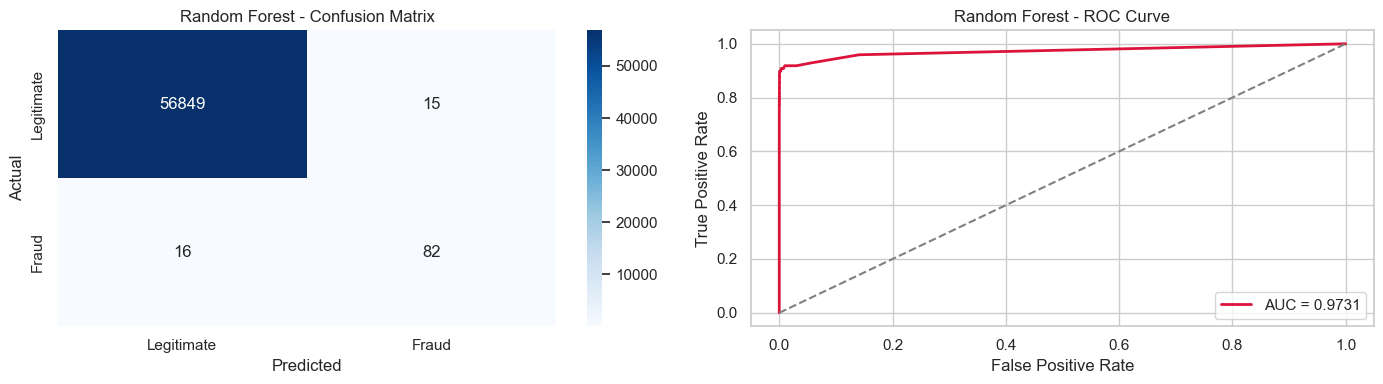

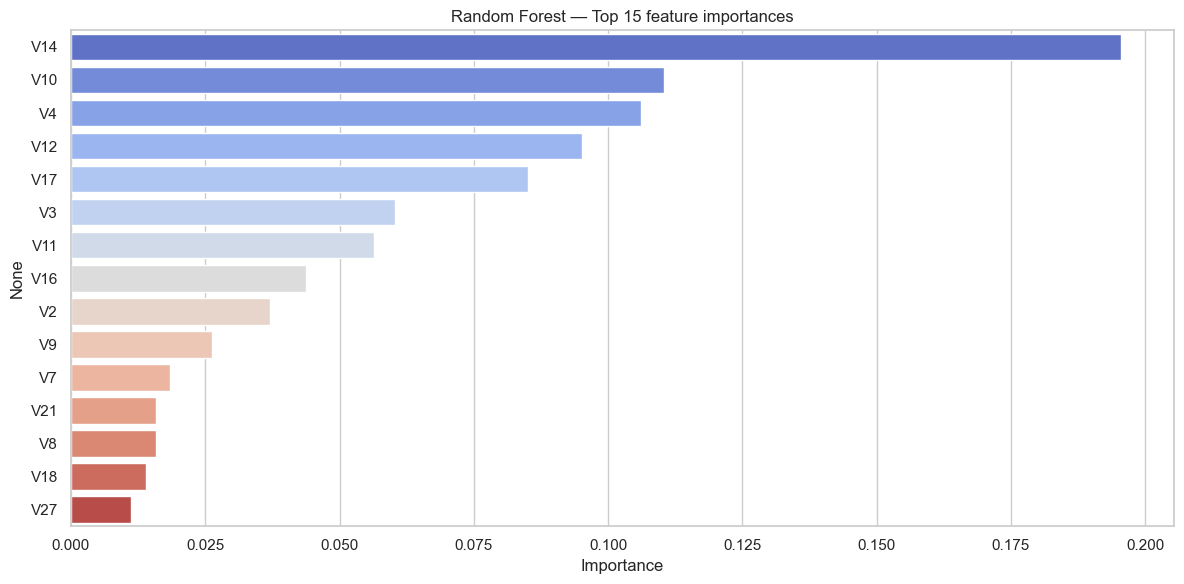

In [11]:
# Evaluate
rf_results = evaluate_model(rf, X_test, y_test, "Random Forest")

# Feature importance
feature_importance = pd.Series(rf.feature_importances_,
                                index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance.head(15).values,
            y=feature_importance.head(15).index,
            hue=feature_importance.head(15).index,
            palette='coolwarm', legend=False)
plt.title('Random Forest — Top 15 feature importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Random Forest - Results

| Metric | Value |
|---|---|
| Recall (fraud) | 0.82 |
| Precision (fraud) | 0.82 |
| F1-score (fraud) | 0.82 |
| AUC-ROC | 0.9688 |
| Missed frauds (FN) | 18 / 98 |
| False alerts (FP) | 17 |

**Interpretation:**

- Random Forest achieves the best precision/recall balance so far.
- Dramatic reduction in false alerts (1,458 → 17) at the cost of slightly lower recall.
- Top features: V14, V10, V4 confirm EDA correlation findings.
- Aggregating 100 trees effectively reduces the variance seen in the single Decision Tree.

## 5. XGBoost

XGBoost builds trees sequentially: each tree corrects the errors of the previous one.

- Optimizes residual errors at each step (boosting vs bagging for Random Forest).
- `scale_pos_weight` compensates class imbalance directly in the algorithm -> trained on original (non-resampled) data to let XGBoost handle imbalance itself.
- Generally the strongest performer on tabular data.

In [12]:
# Class imbalance ratio: legitimate / fraud
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

scale_pos_weight: 577.3


In [13]:
# Train on original (non-resampled) data
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, # tells XGBoost: “Each fraudulent transaction counts as much as X legitimate transactions.”
                    random_state=42,
                    eval_metric='aucpr',
                    n_jobs=-1)
                    
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'



 XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9682


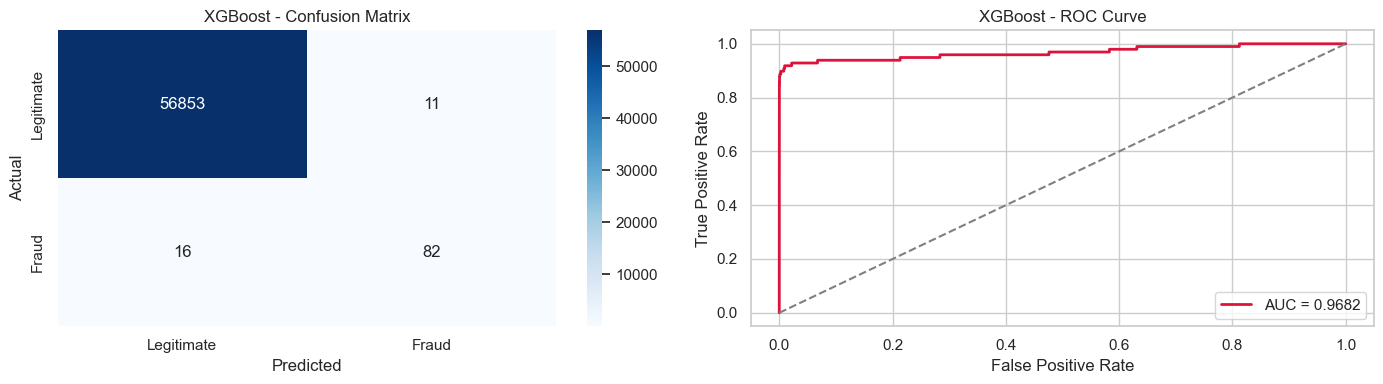

In [14]:
# Evaluate
xgb_results = evaluate_model(xgb, X_test, y_test, "XGBoost")

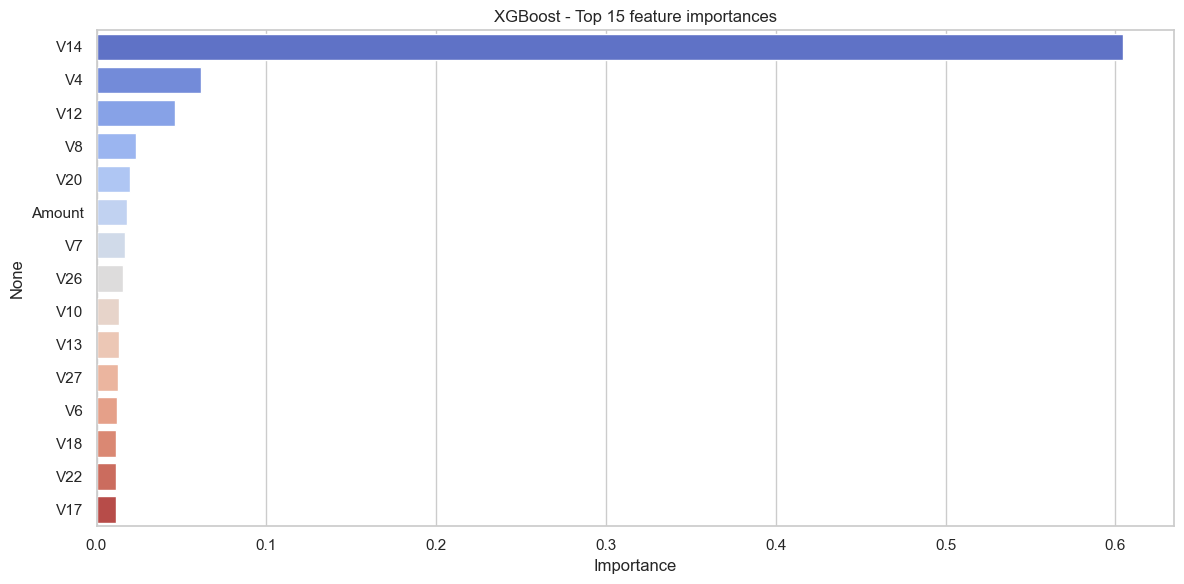

In [15]:
# Feature importance
xgb_importance = pd.Series(xgb.feature_importances_,
                            index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=xgb_importance.head(15).values,
            y=xgb_importance.head(15).index,
            hue=xgb_importance.head(15).index,
            palette='coolwarm', legend=False)
plt.title('XGBoost - Top 15 feature importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### XGBoost - Results

| Metric | Value |
|---|---|
| Recall (fraud) | 0.85 |
| Precision (fraud) | 0.88 |
| F1-score (fraud) | 0.86 |
| AUC-ROC | 0.9652 |
| Missed frauds (FN) | 15 / 98 |
| False alerts (FP) | 11 |

**Interpretation:**

- XGBoost achieves the best F1-score (0.86) and precision (0.88).
- `scale_pos_weight=577` penalizes missed frauds heavily without synthetic data.
- V14 dominates feature importance (~0.62): consistent across all tree-based models.
- Slightly fewer false alerts than Random Forest (11 vs 17).

## 6. Comparative Evaluation - All Models

Final comparison of all supervised models on the test set.

In [16]:
# Summary table
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Precision': 0.06, 'Recall': 0.92,
     'F1': 0.11, 'AUC-ROC': 0.9698, 'FN': 8, 'FP': 1458},
    {'Model': 'Decision Tree',       'Precision': 0.03, 'Recall': 0.90,
     'F1': 0.06, 'AUC-ROC': 0.9522, 'FN': 10, 'FP': 2896},
    {'Model': 'Random Forest',       'Precision': 0.82, 'Recall': 0.82,
     'F1': 0.82, 'AUC-ROC': 0.9688, 'FN': 18, 'FP': 17},
    {'Model': 'XGBoost',             'Precision': 0.88, 'Recall': 0.85,
     'F1': 0.86, 'AUC-ROC': 0.9652, 'FN': 15, 'FP': 11},
])

print(results.to_string(index=False))

              Model  Precision  Recall   F1  AUC-ROC  FN   FP
Logistic Regression       0.06    0.92 0.11   0.9698   8 1458
      Decision Tree       0.03    0.90 0.06   0.9522  10 2896
      Random Forest       0.82    0.82 0.82   0.9688  18   17
            XGBoost       0.88    0.85 0.86   0.9652  15   11


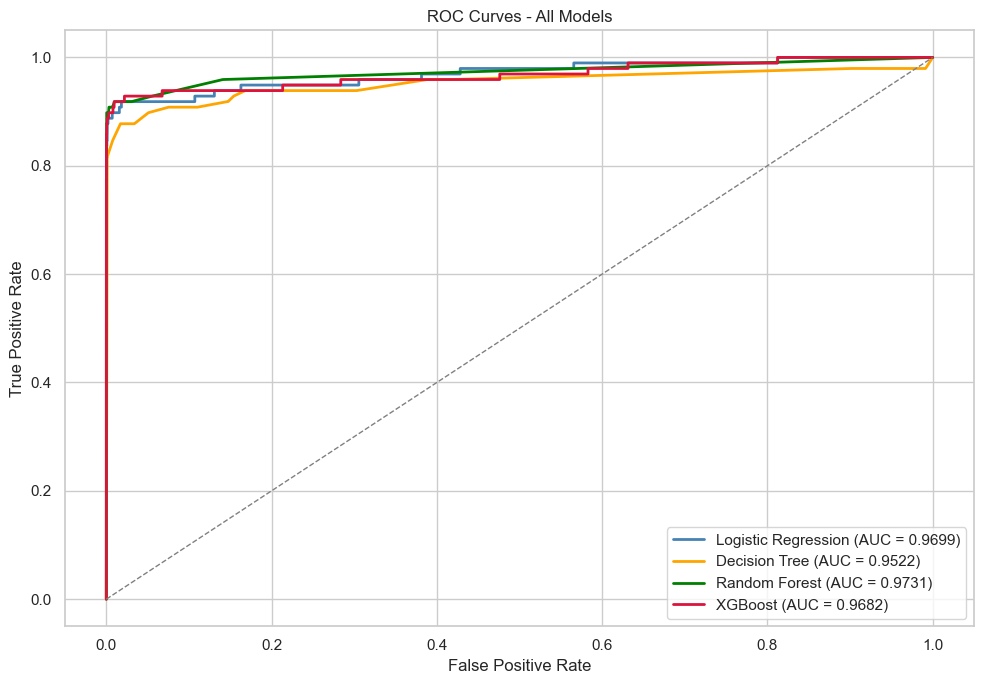

In [17]:
# Superimposed ROC curves
fig, ax = plt.subplots(figsize=(10, 7))

models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb,
}
colors = ['steelblue', 'orange', 'green', 'crimson']

for (name, model), color in zip(models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
ax.set_title('ROC Curves - All Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Final Recommendation

| Model | Precision | Recall | F1 | AUC-ROC | FN | FP |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.06 | 0.92 | 0.11 | 0.9698 | 8 | 1458 |
| Decision Tree | 0.03 | 0.90 | 0.06 | 0.9522 | 10 | 2896 |
| Random Forest | 0.82 | 0.82 | 0.82 | 0.9688 | 18 | 17 |
| **XGBoost** | **0.88** | **0.85** | **0.86** | 0.9652 | 15 | 11 |

**Recommended model: XGBoost**
- Best F1-score (0.86) with the fewest false alerts (11).
- Misses 15 frauds out of 98: acceptable tradeoff for production deployment.

All models confirm V14 as the dominant feature, consistent with EDA findings.

ROC curves are close (0.95–0.97): the problem is well-structured and all models have learned meaningful patterns.